In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.utils import simple_preprocess
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# Convert documents to token indices
def doc2ind(doc, vocab):
    return [vocab.get(word, 0) for word in simple_preprocess(doc)]

In [3]:
# Load GloVe embeddings
def load_glove_embeddings(filepath, embedding_dim=100):
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings


In [4]:
# Prepare dataset (example subset with 5 categories from 20NG)
categories = ['comp.graphics', 'rec.autos', 'sci.space', 'talk.politics.mideast', 'sci.med']
from sklearn.datasets import fetch_20newsgroups
ng_data = fetch_20newsgroups(subset='train', categories=categories)

# Load GloVe
glove_path = "glove.6B.100d.txt"
glove_embeddings = load_glove_embeddings(glove_path)

# Create vocab and index mapping
vocab = {word: idx+1 for idx, word in enumerate(glove_embeddings.keys())}
vocab['<PAD>'] = 0

# Process data
ng_vector_idx = [doc2ind(doc, vocab) for doc in ng_data.data]
max_len = max(len(doc) for doc in ng_vector_idx)
ng_vector_idx = [doc + [0] * (max_len - len(doc)) for doc in ng_vector_idx]
ng_vector_idx = torch.LongTensor(ng_vector_idx)
labels = torch.tensor(ng_data.target)


In [5]:
# Split data into train and test
dataset = TensorDataset(ng_vector_idx, labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

# Define the model
embedding_dim = 100
num_classes = len(categories)

glove_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
    if word in glove_embeddings:
        glove_matrix[idx] = glove_embeddings[word]

glove_tensor = torch.tensor(glove_matrix, dtype=torch.float)

In [6]:
class NNetClassifier(nn.Module):
    def __init__(self, embedding_matrix, num_classes):
        super(NNetClassifier, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix)
        self.embedding.weight.requires_grad = False  # Freeze embeddings initially
        self.fc1 = nn.Linear(embedding_matrix.size(1), 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x).mean(dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return F.log_softmax(self.fc2(x), dim=1)

In [7]:
# Training function
def train_model(model, dataloader, epochs=10, learning_rate=0.005):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_correct += (outputs.argmax(1) == labels).sum().item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}, Accuracy: {total_correct/len(dataloader.dataset):.2f}")


In [8]:
# Test accuracy function
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()
    print(f"Test Accuracy: {correct / len(dataloader.dataset):.2f}")

In [9]:
# Train and evaluate frozen model
model = NNetClassifier(glove_tensor, num_classes)
train_model(model, train_loader)
evaluate_model(model, test_loader)

Epoch 1/10, Loss: 1.5868, Accuracy: 0.26
Epoch 2/10, Loss: 1.5173, Accuracy: 0.34
Epoch 3/10, Loss: 1.4323, Accuracy: 0.39
Epoch 4/10, Loss: 1.3502, Accuracy: 0.45
Epoch 5/10, Loss: 1.2733, Accuracy: 0.52
Epoch 6/10, Loss: 1.2042, Accuracy: 0.58
Epoch 7/10, Loss: 1.1453, Accuracy: 0.59
Epoch 8/10, Loss: 1.0697, Accuracy: 0.65
Epoch 9/10, Loss: 1.0147, Accuracy: 0.67
Epoch 10/10, Loss: 0.9639, Accuracy: 0.70
Test Accuracy: 0.73


In [10]:
# Save frozen embeddings for comparison
frozen_embeddings = model.embedding.weight.detach().cpu().numpy()

# Unfreeze embeddings and fine-tune
model.embedding.weight.requires_grad = True
train_model(model, train_loader)
evaluate_model(model, test_loader)

Epoch 1/10, Loss: 1.6791, Accuracy: 0.45
Epoch 2/10, Loss: 0.8394, Accuracy: 0.72
Epoch 3/10, Loss: 0.6106, Accuracy: 0.80
Epoch 4/10, Loss: 0.5160, Accuracy: 0.83
Epoch 5/10, Loss: 0.3499, Accuracy: 0.90
Epoch 6/10, Loss: 0.2618, Accuracy: 0.93
Epoch 7/10, Loss: 0.1939, Accuracy: 0.95
Epoch 8/10, Loss: 0.2030, Accuracy: 0.94
Epoch 9/10, Loss: 0.1693, Accuracy: 0.95
Epoch 10/10, Loss: 0.1239, Accuracy: 0.97
Test Accuracy: 0.92


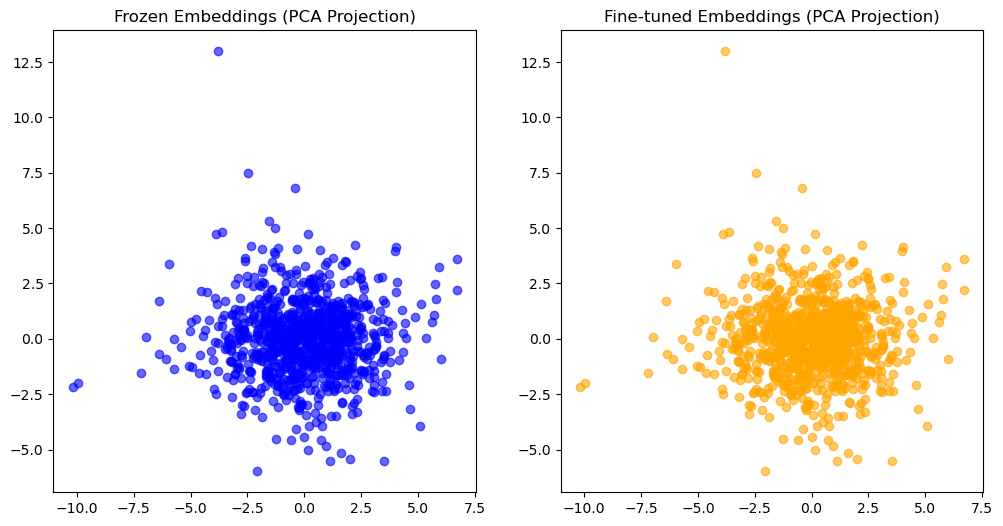

In [11]:
# Visualize embeddings (before and after fine-tuning)
def plot_embeddings(before, after, vocab):
    pca = PCA(n_components=2)
    reduced_before = pca.fit_transform(before[1:1000])
    reduced_after = pca.transform(after[1:1000])

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(reduced_before[:, 0], reduced_before[:, 1], alpha=0.6, color='blue')
    plt.title("Frozen Embeddings (PCA Projection)")
    
    plt.subplot(1, 2, 2)
    plt.scatter(reduced_after[:, 0], reduced_after[:, 1], alpha=0.6, color='orange')
    plt.title("Fine-tuned Embeddings (PCA Projection)")
    
    plt.show()
plot_embeddings(frozen_embeddings, model.embedding.weight.detach().cpu().numpy(), vocab)